# 01 - EDA do preprocessamento THETIS

Este notebook explora os artefatos gerados em data/processed e data/splits.

Objetivos:
- Verificar integridade e cobertura por modalidade/classe.
- Visualizar desbalanceamentos no dataset.
- Conferir distribuição dos splits cross-subject e cross-action.

In [2]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['figure.figsize'] = (10, 5)
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['axes.labelsize'] = 11

In [3]:
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'

manifest_path = DATA_DIR / 'processed' / 'manifest.csv'
integrity_path = DATA_DIR / 'processed' / 'integrity_report.json'
counts_table_path = DATA_DIR / 'processed' / 'counts_by_modality_action.csv'
cross_subject_path = DATA_DIR / 'splits' / 'cross_subject.csv'
cross_action_path = DATA_DIR / 'splits' / 'cross_action.csv'

required_paths = [
    manifest_path,
    integrity_path,
    counts_table_path,
    cross_subject_path,
    cross_action_path,
]

missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing_text = '\n'.join(f'- {path}' for path in missing_paths)
    raise FileNotFoundError(
        'Arquivos de preprocessamento não encontrados. Rode o alvo preprocess antes de executar este notebook:\n'
        f'{missing_text}'
    )

manifest = pd.read_csv(manifest_path)
counts_table = pd.read_csv(counts_table_path)
cross_subject = pd.read_csv(cross_subject_path)
cross_action = pd.read_csv(cross_action_path)

with integrity_path.open('r', encoding='utf-8') as f:
    integrity = json.load(f)

print('Arquivos carregados com sucesso.')
print(f'Manifest: {manifest.shape[0]} linhas x {manifest.shape[1]} colunas')

Arquivos carregados com sucesso.
Manifest: 8374 linhas x 12 colunas


In [4]:
overview = pd.DataFrame(
    {
        'metrica': [
            'total_samples',
            'unique_actors',
            'unique_actions',
            'parse_failure_count',
            'action_mismatch_count',
        ],
        'valor': [
            integrity.get('total_samples'),
            integrity.get('unique_actors'),
            integrity.get('unique_actions'),
            integrity.get('parse_failure_count'),
            integrity.get('action_mismatch_count'),
        ],
    }
)

print('Resumo geral')
display(overview)

display(manifest.head())

Resumo geral


,metrica,valor
0,total_samples,8374
1,unique_actors,55
2,unique_actions,12
3,parse_failure_count,0
4,action_mismatch_count,0


,sample_id,actor_id,actor_index,skill_level,action_id,action_label,modality,modality_dir,sequence_index,action_from_filename,action_mismatch,relative_path
0,p1_backhand_1_depth_66f55010fe,p1,1,beginner,backhand,Backhand,depth,VIDEO_Depth,1,backhand,False,VIDEO_Depth/backhand/p1_backhand_depth_s1.avi
1,p1_backhand_2_depth_2f85042170,p1,1,beginner,backhand,Backhand,depth,VIDEO_Depth,2,backhand,False,VIDEO_Depth/backhand/p1_backhand_depth_s2.avi
2,p1_backhand_3_depth_d71f9165e6,p1,1,beginner,backhand,Backhand,depth,VIDEO_Depth,3,backhand,False,VIDEO_Depth/backhand/p1_backhand_depth_s3.avi
3,p10_backhand_1_depth_5ef65e9ec9,p10,10,beginner,backhand,Backhand,depth,VIDEO_Depth,1,backhand,False,VIDEO_Depth/backhand/p10_backhand_depth_s1.avi
4,p10_backhand_2_depth_5df9cb1246,p10,10,beginner,backhand,Backhand,depth,VIDEO_Depth,2,backhand,False,VIDEO_Depth/backhand/p10_backhand_depth_s2.avi


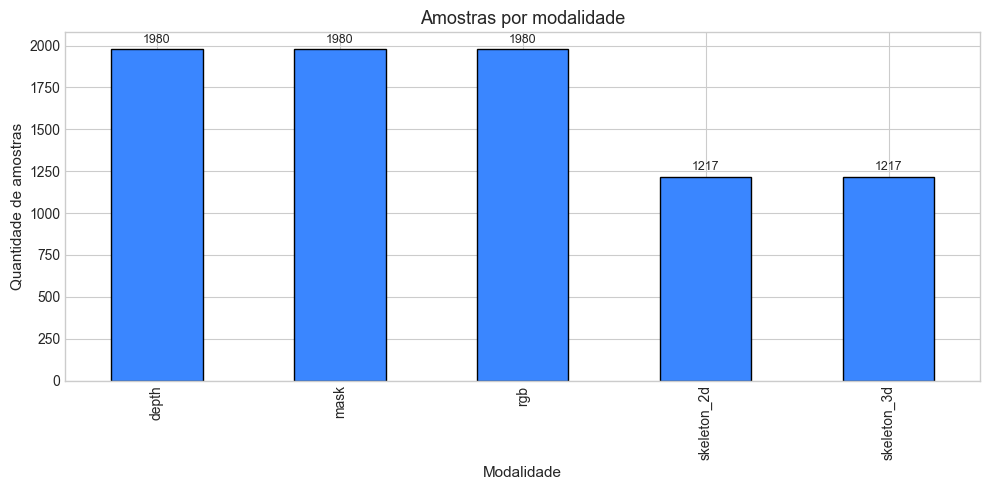

In [5]:
modality_counts = manifest['modality'].value_counts().sort_index()

ax = modality_counts.plot(kind='bar', color='#3A86FF', edgecolor='black')
ax.set_title('Amostras por modalidade')
ax.set_xlabel('Modalidade')
ax.set_ylabel('Quantidade de amostras')

for i, v in enumerate(modality_counts.values):
    ax.text(i, v + max(modality_counts.values) * 0.01, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

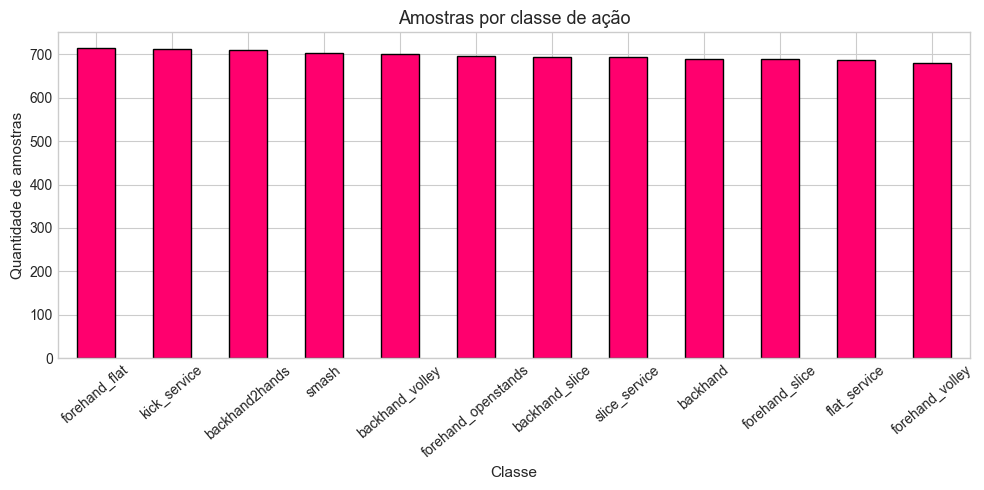

In [6]:
action_counts = manifest['action_id'].value_counts().sort_values(ascending=False)

ax = action_counts.plot(kind='bar', color='#FF006E', edgecolor='black')
ax.set_title('Amostras por classe de ação')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade de amostras')
ax.tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.show()

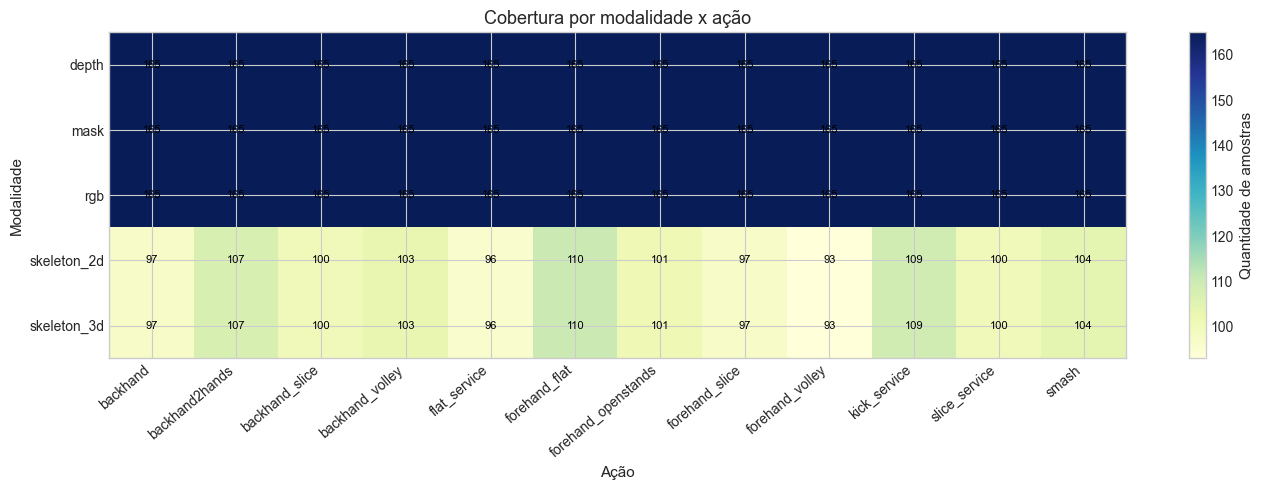

In [7]:
heat = counts_table.pivot(index='modality', columns='action_id', values='count').fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heat.values, cmap='YlGnBu', aspect='auto')

ax.set_title('Cobertura por modalidade x ação')
ax.set_xlabel('Ação')
ax.set_ylabel('Modalidade')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=40, ha='right')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, str(heat.iat[i, j]), ha='center', va='center', color='black', fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Quantidade de amostras')

plt.tight_layout()
plt.show()

,split,count,pct,protocol
0,train,5744,68.59,cross_subject
1,val,1242,14.83,cross_subject
2,test,1388,16.58,cross_subject
3,train,5594,66.80,cross_action
4,val,1376,16.43,cross_action
5,test,1404,16.77,cross_action


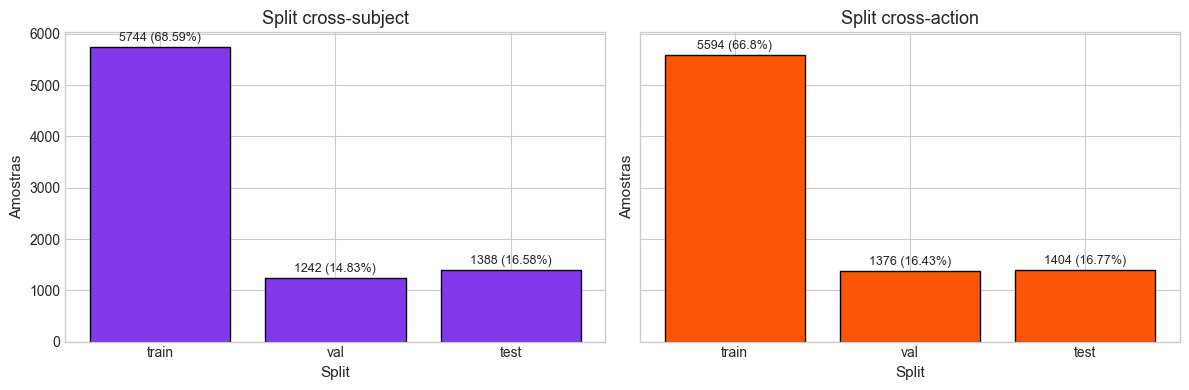

In [9]:
def split_distribution(split_df, protocol_name):
    counts = split_df['split'].value_counts().reindex(['train', 'val', 'test']).fillna(0).astype(int)
    pct = (counts / counts.sum() * 100).round(2)
    out = pd.DataFrame({'split': counts.index, 'count': counts.values, 'pct': pct.values})
    out['protocol'] = protocol_name
    return out

subject_dist = split_distribution(cross_subject, 'cross_subject')
action_dist = split_distribution(cross_action, 'cross_action')
all_dist = pd.concat([subject_dist, action_dist], ignore_index=True)
display(all_dist)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, dist, title, color in [
    (axes[0], subject_dist, 'Split cross-subject', '#8338EC'),
    (axes[1], action_dist, 'Split cross-action', '#FB5607'),
]:
    ax.bar(dist['split'], dist['count'], color=color, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Split')
    ax.set_ylabel('Amostras')
    for i, row in dist.iterrows():
        ax.text(i, row['count'] + dist['count'].max() * 0.01, f'{row["count"]} ({row["pct"]}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()